# El ciclo de vida de un gráfico

Este tutorial muestra el inicio, el desarrollo y el final de una visualización con Matplotlib.
Comenzaremos con datos sin procesar y
terminaremos guardando una figura de una visualización personalizada. A lo largo del tutorial,
destacamos algunas funciones útiles y buenas prácticas de Matplotlib.

## Nuestros datos

Contienen información de ventas de varias empresas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

data = {'Barton LLC': 109438.50,
        'Frami, Hills and Schmidt': 103569.59,
        'Fritsch, Russel and Anderson': 112214.71,
        'Jerde-Hilpert': 112591.43,
        'Keeling LLC': 100934.30,
        'Koepp Ltd': 103660.54,
        'Kulas Inc': 137351.96,
        'Trantow-Barrows': 123381.38,
        'White-Trantow': 135841.99,
        'Will LLC': 104437.60}
group_data = list(data.values())
group_names = list(data.keys())
group_mean = np.mean(group_data)

## Primeros pasos

Estos datos se visualizan naturalmente como un gráfico de barras, con una barra por grupo. Para ello, mediante el enfoque orientado a objetos, primero generamos una instancia de `figure.Figure` y otra de `axes.Axes`. La figura actúa como un lienzo, y los ejes forman parte de ese lienzo, sobre el cual crearemos una visualización específica.




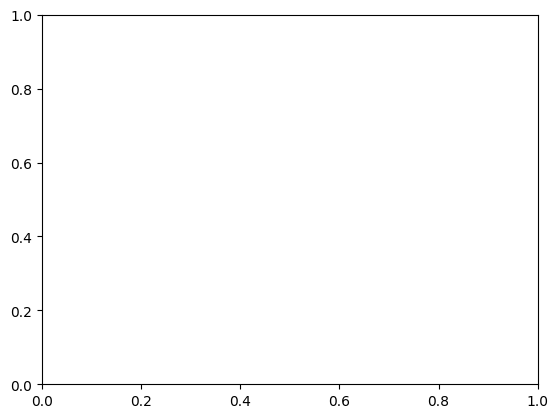

In [2]:
fig, ax = plt.subplots()

Ahora que tenemos una instancia de Axes, podemos graficar sobre ella.


<BarContainer object of 10 artists>

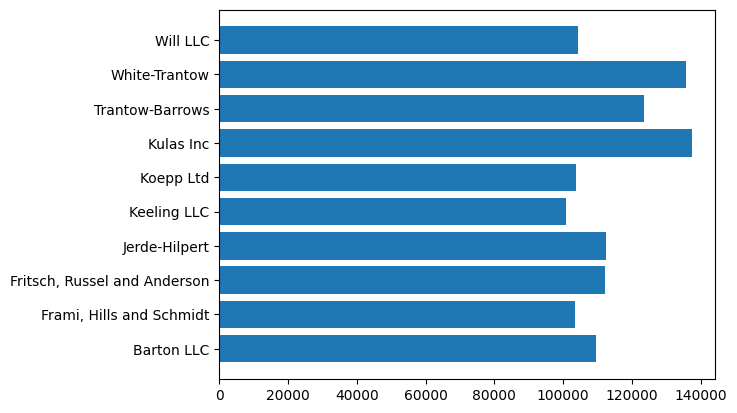

In [3]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)

## Control del estilo

Matplotlib ofrece una gran variedad de estilos para que puedas personalizar tu visualización según tus necesidades. Para ver una lista de estilos, puedes usar:
`.style`.

In [4]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Puedes activar un estilo con lo siguiente:


In [5]:
plt.style.use('fivethirtyeight')

Ahora vamos a rehacer el gráfico anterior para ver cómo queda:


<BarContainer object of 10 artists>

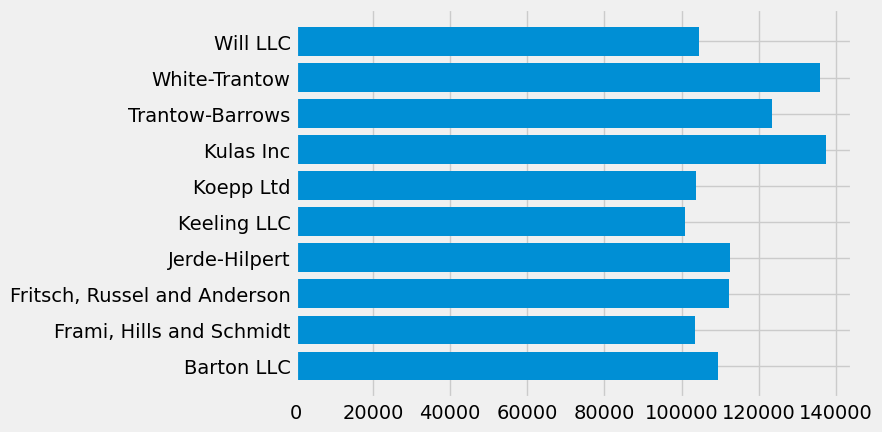

In [6]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)

El estilo controla muchos aspectos, como el color, el grosor de las líneas, los fondos, etc.

## Personalización del gráfico

Ahora que tenemos un gráfico con el aspecto general deseado, vamos a ajustarlo
para que esté listo para imprimir. Primero, giremos las etiquetas del eje x
para que se vean con mayor claridad. Podemos acceder a estas etiquetas
con el método `axes.Axes.get_xticklabels`:

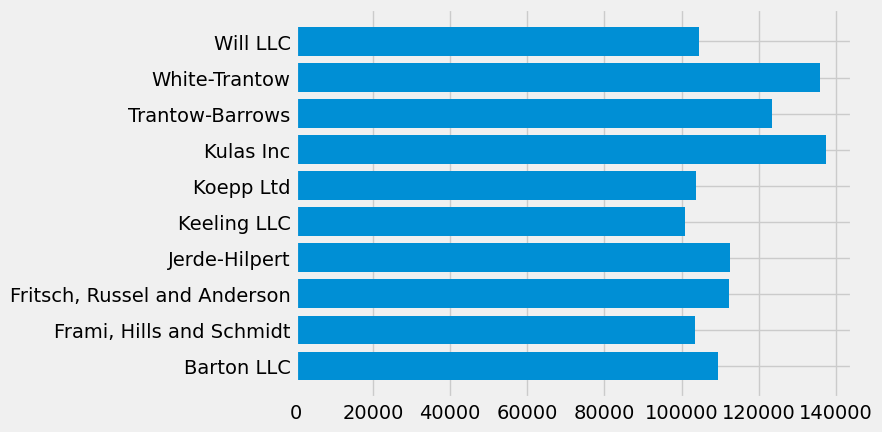

In [7]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()

Si queremos modificar la propiedad de varios elementos a la vez, resulta útil usar la función `pyplot.setp`. Esta función recibe una o varias listas de objetos de Matplotlib e intenta modificar algún elemento de estilo de cada uno.

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

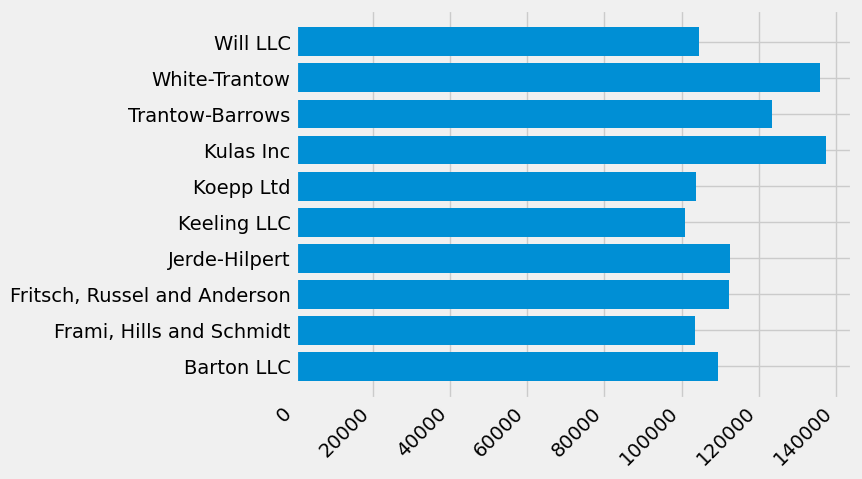

In [9]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

Parece que esto recortó algunas de las etiquetas de la parte inferior. Podemos
indicarle a Matplotlib que deje espacio automáticamente para los elementos en las figuras que creamos. Para ello, establecemos el valor ``autolayout`` de nuestros rcParams. Para obtener más información sobre cómo controlar el estilo, el diseño y otras características de los gráficos con rcParams, consulte `personalización`.

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

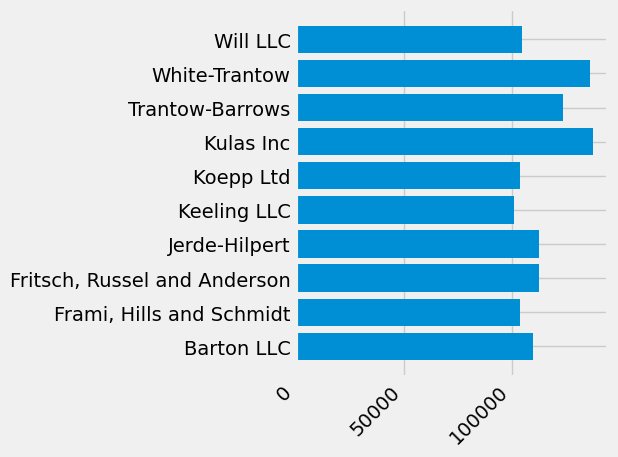

In [10]:
plt.rcParams.update({'figure.autolayout': True})

fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

A continuación, añadimos etiquetas al gráfico. Para ello, con la interfaz orientada a objetos, podemos usar el método `.Artist.set` para establecer las propiedades de este objeto `Axes`.

[(-10000.0, 140000.0),
 Text(0.5, 0, 'Total Revenue'),
 Text(0, 0.5, 'Company'),
 Text(0.5, 1.0, 'Company Revenue')]

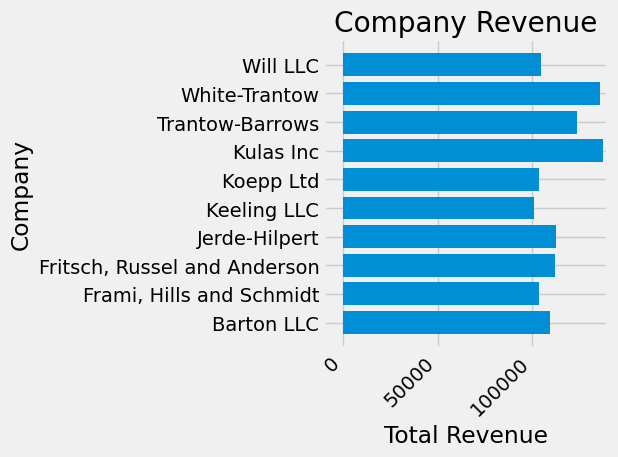

In [11]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
ax.set(xlim=[-10000, 140000], xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')

[(-10000.0, 140000.0),
 Text(0.5, 0, 'Total Revenue'),
 Text(0, 0.5, 'Company'),
 Text(0.5, 1.0, 'Company Revenue')]

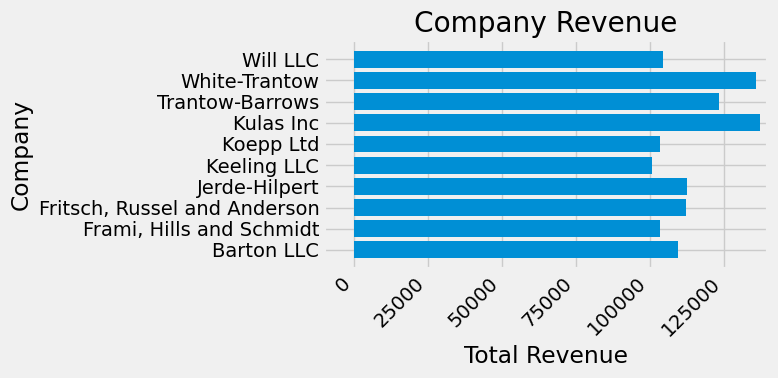

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
ax.set(xlim=[-10000, 140000], xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')

Para las etiquetas, podemos especificar pautas de formato personalizadas mediante funciones. A continuación, definimos una función que recibe un número entero como entrada y devuelve una cadena de texto como salida. Al usarla con `.Axis.set_major_formatter` o `.Axis.set_minor_formatter`, se creará y utilizará automáticamente una clase `ticker.FuncFormatter`.

En esta función, el argumento `x` es la etiqueta original del eje y `pos` es la posición del eje. Aquí solo usaremos `x`, pero ambos argumentos son necesarios.

In [13]:
def currency(x, pos):
    """The two arguments are the value and tick position"""
    if x >= 1e6:
        s = f'${x*1e-6:1.1f}M'
    else:
        s = f'${x*1e-3:1.0f}K'
    return s

Luego podemos aplicar esta función a las etiquetas de nuestro gráfico. Para ello, utilizamos el atributo ``xaxis`` de nuestros ejes. Esto nos permite realizar acciones en un eje específico de nuestro gráfico.

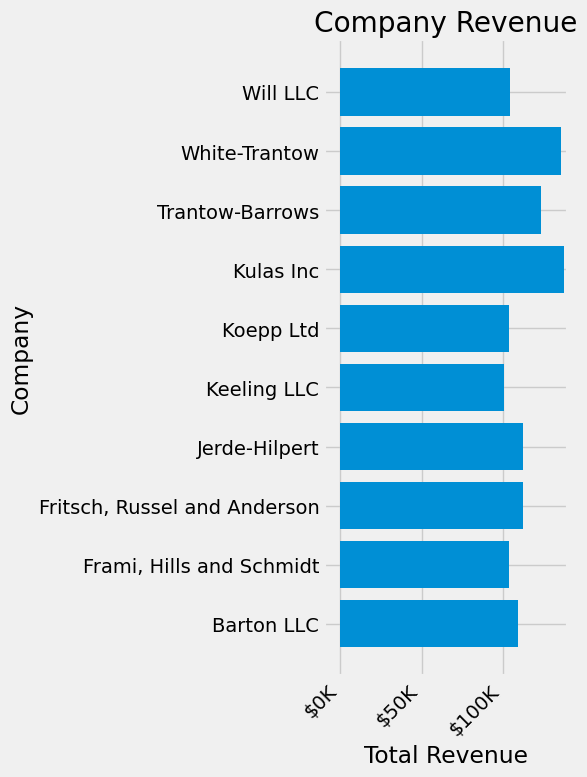

In [14]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

ax.set(xlim=[-10000, 140000], xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')
ax.xaxis.set_major_formatter(currency)

## Combinación de múltiples visualizaciones

Es posible dibujar varios elementos gráficos en la misma instancia de
:class:`axes.Axes`. Para ello, basta con llamar a otro de los
métodos de trazado del objeto Axes.

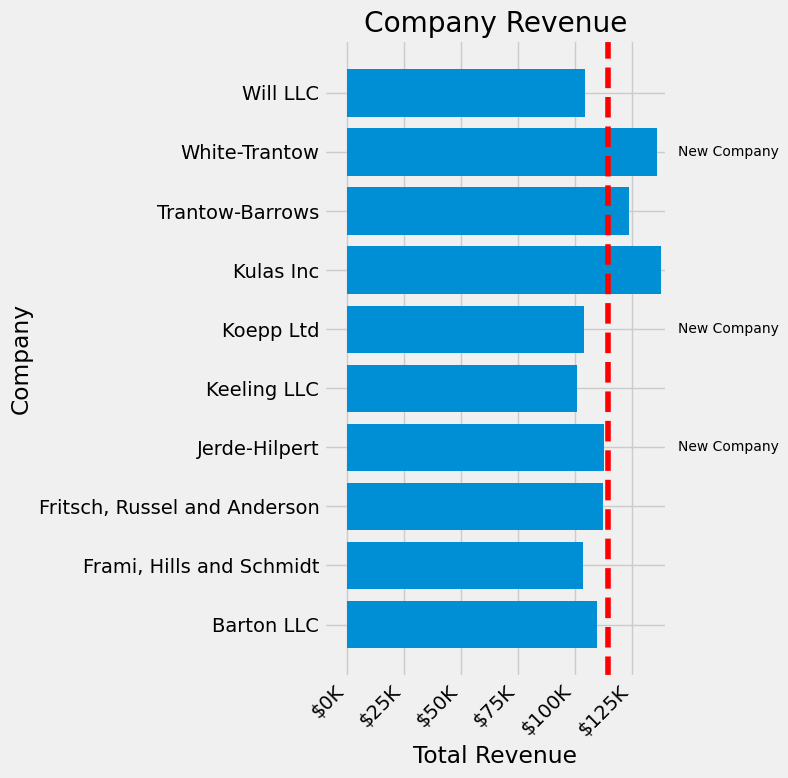

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

# Add a vertical line, here we set the style in the function call
ax.axvline(group_mean, ls='--', color='r')

# Annotate new companies
for group in [3, 5, 8]:
    ax.text(145000, group, "New Company", fontsize=10,
            verticalalignment="center")

# Now we move our title up since it's getting a little cramped
ax.title.set(y=1.05)

ax.set(xlim=[-10000, 140000], xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')
ax.xaxis.set_major_formatter(currency)
ax.set_xticks([0, 25e3, 50e3, 75e3, 100e3, 125e3])
fig.subplots_adjust(right=.1)

plt.show()